Programming Assignment 1: Data Preparation and Understanding
========================

Ethan Ciavolella

Data Mining I

2026/09/11

1: Dataset
-----------

The dataset I chose is the satellite image classification dataset available from Kaggle at https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification/.

It has four classes of images representing different types of terrain/weather conditions as viewed by a satellite: cloudy, desert, green (grass/forest), and ocean.

2: Feature Extraction
------------

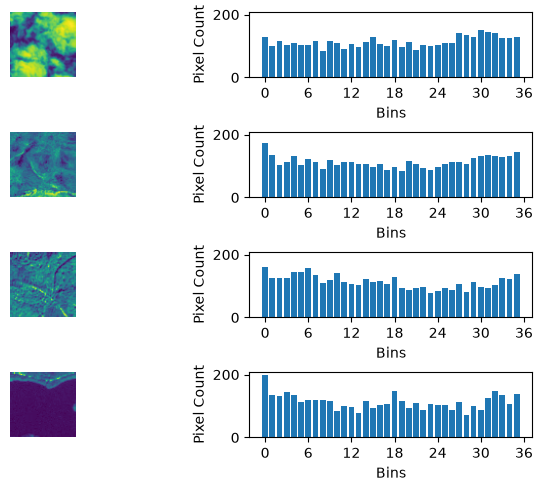

In [7]:
import numpy as np
from skimage import filters, color
import skimage as ski
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# I'm using Pillow instead of the built in skimage reader because
# scikit was having trouble correctly reading one of the images (cloudy.jpg)
from PIL import Image

def angle(dx, dy):
    return np.mod(np.arctan2(dy, dx), np.pi)

image_files = [
    'sample_images/cloudy.jpg',
    'sample_images/desert.jpg',
    'sample_images/green.jpg',
    'sample_images/water.jpg'
]

# Images are different sizes so I am resizing to the lowest size (64x64)
images = [color.rgb2gray(np.asarray(Image.open(f).convert("RGB").resize((64, 64)))) for f in image_files]

angle_sobel = [angle(
    filters.sobel_h(i),
    filters.sobel_v(i)) for i in images]

histograms = [ski.exposure.histogram(i, nbins=36) for i in angle_sobel]

fig = plt.figure(layout="constrained")
axes = fig.subplots(4, 2, sharex='col', sharey='col')

axes[0, 1].set_xlabel('Bins')
axes[0, 1].set_ylabel('Pixel Count')
axes[0, 1].xaxis.set_major_locator(ticker.MultipleLocator(6.0))

for i in range(len(images)):
    axes[i, 0].set_axis_off()
    axes[i, 0].imshow(images[i])

    axes[i, 1].set_xlabel('Bins')
    axes[i, 1].set_ylabel('Pixel Count')
    axes[i, 1].tick_params(axis='x', labelbottom=True)
    axes[i, 1].bar(range(len(histograms[i][0])), histograms[i][0])

plt.show()

For the histogram comparison, I will be using the first image (cloudy.jpg) and the third image (green.jpg)

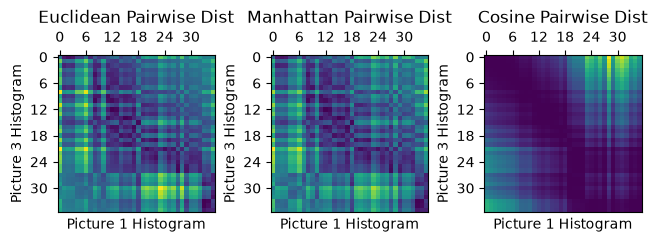

In [8]:
from sklearn import metrics

hist1 = np.column_stack((range(len(histograms[0][0])), histograms[0][0]))
hist2 = np.column_stack((range(len(histograms[2][0])), histograms[2][0]))

euclidean = metrics.pairwise_distances(hist1, hist2)
manhattan = metrics.pairwise_distances(hist1, hist2, 'manhattan')
cosine = metrics.pairwise_distances(hist1, hist2, 'cosine')

fig = plt.figure(layout='constrained')
axes = fig.subplots(1, 3, sharex=True, sharey=True)

axes[0].yaxis_inverted()
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(6.0))
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(6.0))

axes[0].imshow(euclidean)
axes[0].tick_params(axis='x', labeltop=True, top=True, labelbottom=False, bottom=False)
axes[0].set_title('Euclidean Pairwise Dist')
axes[0].set_xlabel('Picture 1 Histogram')
axes[0].set_ylabel('Picture 3 Histogram')

axes[1].imshow(manhattan)
axes[1].tick_params(axis='x', labeltop=True, top=True, labelbottom=False, bottom=False)
axes[1].tick_params(axis='y', labelleft=True)
axes[1].set_title('Manhattan Pairwise Dist')
axes[1].set_xlabel('Picture 1 Histogram')
axes[1].set_ylabel('Picture 3 Histogram')

axes[2].imshow(cosine)
axes[2].tick_params(axis='x', labeltop=True, top=True, labelbottom=False, bottom=False)
axes[2].tick_params(axis='y', labelleft=True)
axes[2].set_title('Cosine Pairwise Dist')
axes[2].set_xlabel('Picture 1 Histogram')
axes[2].set_ylabel('Picture 3 Histogram')

plt.show()

3: Histogram Oriented Gradient
-----------

I will be using image #4 (the ocean).

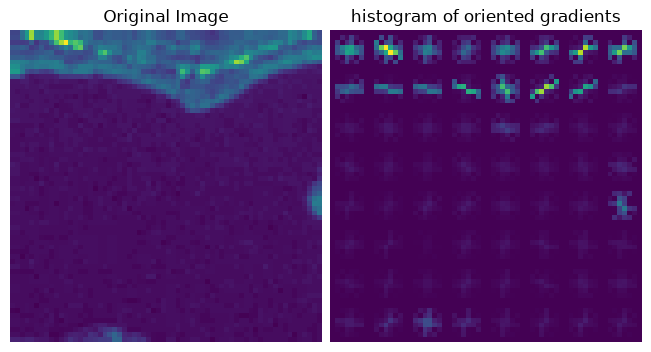

In [9]:
from skimage.feature import hog
from skimage import exposure

fd, hog_img = hog(
    images[3],
    orientations=8,
    pixels_per_cell=(8,8),
    cells_per_block=(1,1),
    visualize=True
)

fig = plt.figure(layout="constrained")
axes = fig.subplots(1, 2)

axes[0].set_axis_off()
axes[0].set_title('Original Image')
axes[0].imshow(images[3])

axes[1].set_axis_off()
axes[1].set_title('histogram of oriented gradients')
axes[1].imshow(exposure.rescale_intensity(hog_img, in_range=(0,10)))

plt.show()


4: Dimensionality Reduction with Principal Component Analysis
---------

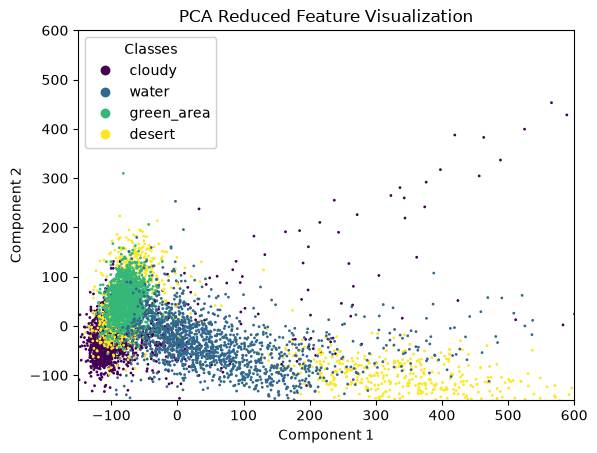

In [10]:
from pathlib import Path
from sklearn.decomposition import PCA

data_dir = Path('./images')
image_files = [path.relative_to('.') for path in data_dir.rglob("*.jpg")]

classes = ['cloudy', 'water', 'green_area', 'desert']

image_classes = [classes.index(path.parts[1]) for path in image_files]

images = [color.rgb2gray(np.asarray(Image.open(f).convert("RGB").resize((64, 64)))) for f in image_files]

angle_sobel = [angle(
    filters.sobel_h(i),
    filters.sobel_v(i)) for i in images]

histograms = [ski.exposure.histogram(i, nbins=36)[0] for i in angle_sobel]

fit = PCA(n_components=2).fit_transform(histograms)

fig, ax = plt.subplots()
scatter = ax.scatter(fit[:,0], fit[:,1], c=image_classes, s=1.0)

handles, _ = scatter.legend_elements()
legend = ax.legend(handles, classes, loc="upper left", title="Classes")

ax.add_artist(legend)

ax.set_xlim(-150, 600)
ax.set_ylim(-150, 600)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_title('PCA Reduced Feature Visualization')

plt.show()



Unfortunately, there really were not clearly separable classes. At a glance, the most distinct class is 'water'. If the cloudy images were discarded, this model could be reasonably good at distinguishing land versus water images. Practically speaking, a better way to classify these images would be use color data.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import json

text = []
with open('student_1/train.json', 'r') as f:
    for line in f:
        text.append(json.loads(line))

content = [tweet['Tweet'] for tweet in text]

count_vector = CountVectorizer().fit(content)
tfidf_vector = TfidfVectorizer().fit(content)

print(f"Count vector dimensionality: {len(count_vector.get_feature_names_out())}")
print(f"TF-IDF vector dimensionality: {len(tfidf_vector.get_feature_names_out())}")


Count vector dimensionality: 9608
TF-IDF vector dimensionality: 9608


The four classes I chose for the principal components analysis are anger, joy, fear and sadness.

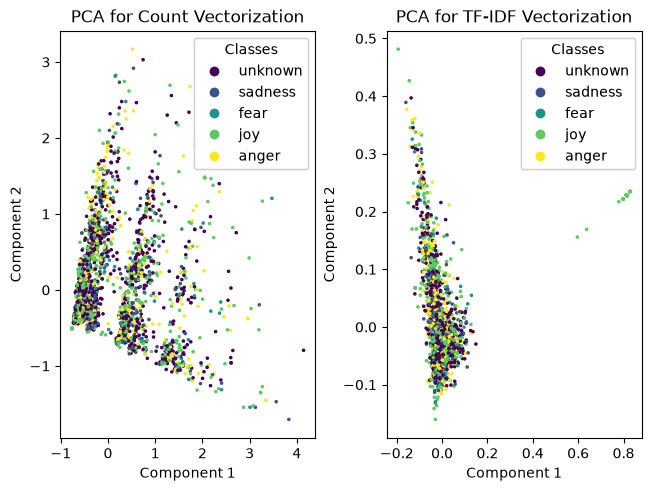

In [13]:
classes = ['unknown', 'sadness', 'fear', 'joy', 'anger']

def tweet_class(tweet):
    matches = 0
    tweet_class = None

    if tweet['sadness'] == True:
        matches += 1
        tweet_class = classes.index('sadness')

    if tweet['fear'] == True:
        matches += 1
        tweet_class = classes.index('fear')

    if tweet['joy'] == True:
        matches += 1
        tweet_class = classes.index('joy')

    if tweet['anger'] == True:
        matches += 1
        tweet_class = classes.index('anger')

    if matches == 1:
        return tweet_class
    else:
        return 0

count_results = count_vector.transform(content).toarray()
tfidf_results = tfidf_vector.transform(content).toarray()

count_fit = PCA(n_components=2).fit_transform(count_results)
tfidf_fit = PCA(n_components=2).fit_transform(tfidf_results)

tweet_classes = [tweet_class(tweet) for tweet in text]

fig = plt.figure(layout="constrained")
axes = fig.subplots(1, 2)

scatter = axes[0].scatter(count_fit[:,0], count_fit[:,1], c=tweet_classes, s=2.5)
axes[1].scatter(tfidf_fit[:,0], tfidf_fit[:,1], c=tweet_classes, s=2.5)

handles, _ = scatter.legend_elements()
legend0 = axes[0].legend(handles, classes, loc="upper right", title="Classes")
legend1 = axes[1].legend(handles, classes, loc="upper right", title="Classes")

axes[0].add_artist(legend0)
axes[0].set_title('PCA for Count Vectorization')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')

axes[1].add_artist(legend1)
axes[1].set_title('PCA for TF-IDF Vectorization')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

plt.show()

Unfortunately, the classes were even less separable than in the case of the image data.